# **Emo-ResNet50V2**
An Emotion Aware Resnet50V2 for Mental Health Detection

## Importing Dependencies

In [ ]:
import kagglehub
import os
!pip install visualkeras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn
import skimage.io
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras.layers import Dense, Flatten, Dropout,BatchNormalization ,Activation
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Conv2D, GlobalAveragePooling2D, LeakyReLU
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint, EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications.nasnet import NASNetLarge
from tensorflow.keras.models import load_model
from tensorflow.keras import backend as K
import shutil

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 21.2 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Loading Datasets

In [ ]:
zip_file = '/content/affectnet.zip'
extract_folder = 'affectnet_img'
shutil.unpack_archive(zip_file, extract_folder, 'zip')

zip_file = '/content/FER2013.zip'
extract_folder = 'fer2013_img'
shutil.unpack_archive(zip_file, extract_folder, 'zip')

In [ ]:
!rm -rf affectnet_img/Train/.ipynb_checkpoints
!rm -rf affectnet_img/Train/contempt/
!rm -rf affectnet_img/Test/Contempt/
!rm -rf affectnet_img/Test/.ipynb_checkpoints

print(sorted(os.listdir('/content/affectnet_img/Train')))

print(sorted(os.listdir('/content/affectnet_img/Test')))

['anger', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
['anger', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [ ]:
print(sorted(os.listdir('/content/fer2013_img/Train')))

print(sorted(os.listdir('/content/fer2013_img/Test')))

['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


### Preprocessing for FER2013 and Affectnet Datasets

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.25,
    height_shift_range=0.25,
    shear_range=0.2,
    zoom_range=0.3,
    horizontal_flip=True,
    brightness_range=[0.6, 1.4],
    fill_mode='nearest',
    validation_split=0.2
)

valid_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_dataset = train_datagen.flow_from_directory(
    directory = '/content/affectnet_img/Train',
    target_size=(224, 224),
    class_mode='categorical',
    color_mode='rgb',
    subset='training',
    batch_size=64
)

valid_dataset = valid_datagen.flow_from_directory(
    directory='/content/affectnet_img/Train' ,
    target_size=(224, 224),
    class_mode='categorical',
    color_mode='rgb',
    subset='validation',
    batch_size=64,
    shuffle=False
)

test_dataset = test_datagen.flow_from_directory(
    directory='/content/affectnet_img/Test',
    target_size=(224, 224),
    class_mode='categorical',
    color_mode='rgb',
    batch_size=64
)

Found 11642 images belonging to 7 classes.
Found 2907 images belonging to 7 classes.
Found 13206 images belonging to 7 classes.


In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.25,
    height_shift_range=0.25,
    shear_range=0.2,
    zoom_range=0.3,
    horizontal_flip=True,
    brightness_range=[0.6, 1.4],
    fill_mode='nearest',
    validation_split=0.2
)

valid_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_dataset = train_datagen.flow_from_directory(
    directory = '/content/fer2013_img/Train',
    target_size=(224, 224),
    class_mode='categorical',
    color_mode='rgb',
    subset='training',
    batch_size=64
)

valid_dataset = valid_datagen.flow_from_directory(
    directory='/content/fer2013_img/Train' ,
    target_size=(224, 224),
    class_mode='categorical',
    color_mode='rgb',
    subset='validation',
    batch_size=64,
    shuffle=False
)

test_dataset = test_datagen.flow_from_directory(
    directory='/content/fer2013_img/Test',
    target_size=(224, 224),
    class_mode='categorical',
    color_mode='rgb',
    batch_size=64
)

### Constructing Base Model + Emo-Aware Layer

In [ ]:
base_model = tf.keras.applications.ResNet50V2(input_shape=(224,224,3), include_top=False, weights="imagenet")

for layer in base_model.layers[:-4]:
    layer.trainable=False

class SpatialAttention(tf.keras.layers.Layer):
    def __init__(self):
        super(SpatialAttention, self).__init__()
        self.conv = Conv2D(1, 7, padding='same', activation='sigmoid')

    def call(self, x):
        avg_pool = tf.reduce_mean(x, axis=-1, keepdims=True)
        max_pool = tf.reduce_max(x, axis=-1, keepdims=True)
        concat = tf.concat([avg_pool, max_pool], axis=-1)
        attention = self.conv(concat)
        return tf.multiply(x, attention)


model = Sequential()
model.add(base_model)
model.add(SpatialAttention())
model.add(GlobalAveragePooling2D())
model.add(Dense(128, kernel_regularizer=l2(0.0005)))
model.add(BatchNormalization())
model.add(LeakyReLU(alpha=0.1))
model.add(Dropout(0.35))
model.add(Dense(7, activation='softmax'))

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50v2 (Functional)         │ (None, 7, 7, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_attention_1             │ (None, 7, 7, 2048)     │            99 │
│ (SpatialAttention)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,828,586 (90.90 MB)

 Trainable params: 1,318,250 (5.03 MB)

 Non-trainable params: 22,510,336 (85.87 MB)

In [ ]:
lrd = ReduceLROnPlateau(monitor = 'val_loss',patience = 20,verbose = 1,factor = 0.50, min_lr = 1e-7, mode='min')

mcp = ModelCheckpoint('/content/model_affectnet_checkpoint.keras', save_best_only=True, verbose = 1)

es = EarlyStopping(verbose=1, patience=20, restore_best_weights=True)

### Metrics

In [ ]:

METRICS = [
    tf.keras.metrics.CategoricalAccuracy(name='accuracy'),
    tf.keras.metrics.Precision(name='precision', class_id=None),
    tf.keras.metrics.Recall(name='recall', class_id=None),
    tf.keras.metrics.AUC(name='auc', multi_label=False),
]


def f1_score(y_true, y_pred):
    # Convert to class indices
    y_true = K.argmax(y_true, axis=-1)
    y_pred = K.argmax(y_pred, axis=-1)

    # One-hot encode for calculation
    y_true_oh = K.one_hot(K.cast(y_true, 'int32'), 7)
    y_pred_oh = K.one_hot(K.cast(y_pred, 'int32'), 7)

    # Calculate metrics using one-hot encoded vectors
    true_positives = K.sum(y_true_oh * y_pred_oh, axis=0)
    possible_positives = K.sum(y_true_oh, axis=0)
    predicted_positives = K.sum(y_pred_oh, axis=0)

    precision = true_positives / (predicted_positives + K.epsilon())
    recall = true_positives / (possible_positives + K.epsilon())

    f1 = 2 * precision * recall / (precision + recall + K.epsilon())

    # Handle NaN values
    f1 = tf.where(tf.math.is_nan(f1), tf.zeros_like(f1), f1)

    # Return macro F1 (average across classes)
    return K.mean(f1)

METRICS.append(f1_score)

In [ ]:

import os
import random
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from tqdm import tqdm
import tensorflow as tf
from tensorflow.keras.preprocessing.image import img_to_array, array_to_img, load_img, save_img
from tensorflow.keras.models import load_model

# deterministic seeds


# Load pretrained model weights (already instantiated earlier)
model.load_weights("/content/model_affectnet_checkpoint.keras")

def add_awgn(img, mean=0.0, std=0.1):
    gauss = np.random.normal(mean, std, img.shape).astype('float32')
    noisy_img = img + gauss
    return np.clip(noisy_img, 0.0, 1.0)

def add_salt_pepper(img, salt_prob=0.02, pepper_prob=0.02):
    noisy = img.copy()
    h, w = noisy.shape[0], noisy.shape[1]
    num_salt = int(np.ceil(salt_prob * h * w))
    num_pepper = int(np.ceil(pepper_prob * h * w))
    coords = [np.random.randint(0, i, num_salt) for i in (h, w)]
    noisy[coords[0], coords[1], :] = 1.0
    coords = [np.random.randint(0, i, num_pepper) for i in (h, w)]
    noisy[coords[0], coords[1], :] = 0.0
    return noisy

def add_rvin(img, prob=0.02):
    noisy_img = img.copy()
    h, w, c = noisy_img.shape
    num_rvin = int(np.ceil(prob * h * w))
    ys = np.random.randint(0, h, num_rvin)
    xs = np.random.randint(0, w, num_rvin)
    chs = np.random.randint(0, c, num_rvin)
    vals = np.random.uniform(0, 1, num_rvin).astype('float32')
    noisy_img[ys, xs, chs] = vals
    return noisy_img

def add_mixed_noise(img, mean=0.0, std=0.05, salt_prob=0.01, pepper_prob=0.01, rvin_prob=0.005):
    out = add_awgn(img, mean, std)
    out = add_salt_pepper(out, salt_prob, pepper_prob)
    out = add_rvin(out, rvin_prob)
    return np.clip(out, 0.0, 1.0)

def add_nothing(img):
  return img

def load_and_preprocess_rgb(image_path, target_size=(224,224)):
    img = load_img(image_path, target_size=target_size, color_mode='rgb')
    arr = img_to_array(img).astype('float32') / 255.0
    if arr.ndim == 2:
        arr = cv2.cvtColor(arr, cv2.COLOR_GRAY2RGB)
    if arr.shape[2] == 1:
        arr = np.repeat(arr, 3, axis=2)
    return arr

def process_one_random_image_per_emotion(src_folder, dest_folder_noisy, dest_folder_original, noise_function=add_mixed_noise, target_size=(224,224)):
    os.makedirs(dest_folder_noisy, exist_ok=True)
    os.makedirs(dest_folder_original, exist_ok=True)

    records = []
    emotions = sorted([d for d in os.listdir(src_folder) if os.path.isdir(os.path.join(src_folder, d))])
    for sub_dir in tqdm(emotions, desc="Processing one random image per emotion"):
        sub_dir_path = os.path.join(src_folder, sub_dir)
        img_files = [f for f in os.listdir(sub_dir_path) if f.lower().endswith(('jpg', 'png', 'jpeg'))]
        if not img_files:
            continue
        selected_file = random.choice(img_files)
        img_path = os.path.join(sub_dir_path, selected_file)
        arr = load_and_preprocess_rgb(img_path, target_size=target_size)

        dest_noisy_sub = os.path.join(dest_folder_noisy, sub_dir)
        dest_orig_sub = os.path.join(dest_folder_original, sub_dir)
        os.makedirs(dest_noisy_sub, exist_ok=True)
        os.makedirs(dest_orig_sub, exist_ok=True)

        base_name, ext = os.path.splitext(selected_file)
        orig_filename = f"{base_name}{ext}"
        noisy_filename = f"{base_name}_noisy{ext}"

        save_img(os.path.join(dest_orig_sub, orig_filename), array_to_img(arr))
        noisy_arr = noise_function(arr)
        save_img(os.path.join(dest_noisy_sub, noisy_filename), array_to_img(noisy_arr))

        records.append({
            "true_label": sub_dir,
            "orig_path": os.path.join(dest_orig_sub, orig_filename),
            "noisy_path": os.path.join(dest_noisy_sub, noisy_filename)
        })

    print(f"Processed {len(records)} images (one per emotion where available).")
    return records

def build_condition_weights_from_survey(survey_csv_path):
    df = pd.read_csv(survey_csv_path)
    df.replace('N/A', np.nan, inplace=True)

    if 'Emotion' not in df.columns:
        raise ValueError("CSV must include an 'Emotion' column (with entries: anxiety, depression, stress)")

    df['Emotion'] = df['Emotion'].str.lower().str.strip()

    # Compute mean of repeated entries if any
    emotion_columns = [col for col in df.columns if col.lower() != 'emotion']
    grouped = df.groupby('Emotion')[emotion_columns].mean().fillna(0.0)

    # Normalize each row (condition) to [0,1]
    grouped_norm = grouped.div(grouped.max(axis=1), axis=0)
    grouped_norm = grouped_norm.clip(0.0, 1.0)

    print("\nNormalized survey weights per condition (0–1 scale):")
    print(grouped_norm)
    return grouped_norm

def calculate_condition(output_vector, weights_df, class_order):
    col_map = {col.lower(): col for col in weights_df.columns}
    scores = {cond: 0.0 for cond in weights_df.index}

    for i, prob in enumerate(output_vector):
        emotion = class_order[i].lower()
        if emotion in col_map:
            col_name = col_map[emotion]
            for cond in weights_df.index:
                scores[cond] += prob * float(weights_df.loc[cond, col_name])

    total = sum(scores.values())
    if total > 0:
        scores = {k: v for k, v in scores.items()}

    inferred = max(scores, key=scores.get)
    return scores, inferred

def show_and_evaluate_records(model, weights_df, records, class_order, out_csv_path='/content/predictions_summary.csv'):
    rows = []
    correct = 0
    total = 0

    for rec in records:
        true_label = rec['true_label'].lower()
        # img_path = rec['noisy_path']
        img_path = rec['orig_path']
        arr = load_and_preprocess_rgb(img_path, target_size=(224,224))
        preds = model.predict(np.expand_dims(arr, axis=0), verbose=0)[0]
        pred_idx = int(np.argmax(preds))
        predicted_label = class_order[pred_idx].lower()

        # Calculate condition
        cond_scores, inferred_condition = calculate_condition(preds, weights_df, class_order)
        is_correct = (predicted_label == true_label)
        correct += int(is_correct)
        total += 1

        # Print full probabilities and condition data
        print(f"\nTrue Class: {true_label.capitalize()}")
        print(f"Predicted Class: {predicted_label.capitalize()}")
        for i, emo in enumerate(class_order):
            print(f"{emo.capitalize()}: {preds[i]:.6f}")
        print(f"Condition: {inferred_condition}")
        print("Scores:", cond_scores, "\n")

        plt.figure(figsize=(4,4))
        plt.imshow(arr)
        plt.title(f"True: {true_label} | Pred: {predicted_label}")
        plt.axis('off')
        plt.show()

        row = {
            'image_path': img_path,
            'true_label': true_label,
            'predicted_label': predicted_label,
            'inferred_condition': inferred_condition
        }
        for i, name in enumerate(class_order):
            row[f'prob_{name}'] = float(preds[i])
        for cond, val in cond_scores.items():
            row[f'{cond}_score'] = val
        rows.append(row)

    df_out = pd.DataFrame(rows)
    if not df_out.empty:
        df_out.to_csv(out_csv_path, index=False)
        print(f"Saved prediction summary to: {out_csv_path}")

    if total > 0:
        accuracy = (correct / total) * 100.0
        print(f"Overall accuracy on selected images: {accuracy:.2f}% ({correct}/{total})")
    else:
        print("No images processed!")

    return df_out

CLASS_ORDER = ['anger','disgust','fear','happy','neutral','sad','surprise']

### Loading model weights for Training

In [ ]:
model.load_weights('/content/model_fer2013_checkpoint.keras')

In [ ]:
model.compile(optimizer=Adam(1e-3),loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05), metrics=METRICS)

## For Balancing Imbalanced Dataset

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Compute class weights
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(train_dataset.classes),
    y=train_dataset.classes
)
class_weight_dict = dict(enumerate(class_weights))
class_weight_dict = {k: min(v, 3.0) for k, v in class_weight_dict.items()}

csv_logger = tf.keras.callbacks.CSVLogger('/content/affectnet_training_log.csv', separator=',', append=True)

### Training 40 epochs

In [ ]:

history = model.fit(
    train_dataset,
    validation_data=valid_dataset,
    epochs=20,
    class_weight=class_weight_dict,
    callbacks=[lrd, mcp, es, csv_logger]
)

Epoch 1/20
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 921ms/step - accuracy: 0.2279 - auc: 0.6084 - f1_score: 0.2030 - loss: 2.4228 - precision: 0.2937 - recall: 0.0826

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()



Epoch 1: val_loss improved from inf to 1.72224, saving model to /content/drive/MyDrive/Renan_ResNet50V2/model_fer2013.keras
359/359 ━━━━━━━━━━━━━━━━━━━━ 372s 992ms/step - accuracy: 0.2280 - auc: 0.6086 - f1_score: 0.2031 - loss: 2.4222 - precision: 0.2939 - recall: 0.0826 - val_accuracy: 0.4200 - val_auc: 0.7936 - val_f1_score: 0.3530 - val_loss: 1.7222 - val_precision: 0.5787 - val_recall: 0.2184 - learning_rate: 0.0010
Epoch 2/20
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 893ms/step - accuracy: 0.3379 - auc: 0.7247 - f1_score: 0.2987 - loss: 1.8719 - precision: 0.5481 - recall: 0.1194
Epoch 2: val_loss improved from 1.72224 to 1.60620, saving model to /content/drive/MyDrive/Renan_ResNet50V2/model_fer2013.keras
359/359 ━━━━━━━━━━━━━━━━━━━━ 332s 926ms/step - accuracy: 0.3379 - auc: 0.7248 - f1_score: 0.2987 - loss: 1.8719 - precision: 0.5481 - recall: 0.1195 - val_accuracy: 0.4588 - val_auc: 0.8130 - val_f1_score: 0.3652 - val_loss: 1.6062 - val_precision: 0.6498 - val_recall: 0.2052 - learning_

In [ ]:
history = model.fit(
    train_dataset,
    validation_data=valid_dataset,
    epochs=30,
    class_weight=class_weight_dict,  # Add this
    callbacks=[lrd, mcp, es, csv_logger],
    initial_epoch=20
)

Epoch 21/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 885ms/step - accuracy: 0.4601 - auc: 0.8250 - f1_score: 0.4001 - loss: 1.4349 - precision: 0.6645 - recall: 0.2303
Epoch 21: val_loss did not improve from 1.31474
359/359 ━━━━━━━━━━━━━━━━━━━━ 328s 914ms/step - accuracy: 0.4601 - auc: 0.8250 - f1_score: 0.4001 - loss: 1.4349 - precision: 0.6645 - recall: 0.2303 - val_accuracy: 0.5290 - val_auc: 0.8637 - val_f1_score: 0.4432 - val_loss: 1.3353 - val_precision: 0.6860 - val_recall: 0.3524 - learning_rate: 5.0000e-04
Epoch 22/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 884ms/step - accuracy: 0.4628 - auc: 0.8253 - f1_score: 0.4060 - loss: 1.4224 - precision: 0.6735 - recall: 0.2291
Epoch 22: val_loss did not improve from 1.31474
359/359 ━━━━━━━━━━━━━━━━━━━━ 328s 914ms/step - accuracy: 0.4628 - auc: 0.8253 - f1_score: 0.4060 - loss: 1.4224 - precision: 0.6735 - recall: 0.2291 - val_accuracy: 0.5119 - val_auc: 0.8550 - val_f1_score: 0.4394 - val_loss: 1.3828 - val_precision: 0.6472 - val_recall: 0.3538 - le

In [ ]:
history = model.fit(
    train_dataset,
    validation_data=valid_dataset,
    epochs=35,
    class_weight=class_weight_dict,  # Add this
    callbacks=[lrd, mcp, es, csv_logger],
    initial_epoch=30
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 31/35
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5578 - auc: 0.8824 - f1_score: 0.4956 - loss: 1.2713 - precision: 0.7814 - recall: 0.3068
Epoch 31: val_loss improved from inf to 1.40175, saving model to /content/drive/MyDrive/Renan_ResNet50V2/model_fer2013.keras
359/359 ━━━━━━━━━━━━━━━━━━━━ 438s 1s/step - accuracy: 0.5578 - auc: 0.8824 - f1_score: 0.4956 - loss: 1.2713 - precision: 0.7815 - recall: 0.3068 - val_accuracy: 0.5574 - val_auc: 0.8796 - val_f1_score: 0.4741 - val_loss: 1.4018 - val_precision: 0.7577 - val_recall: 0.3323 - learning_rate: 2.0000e-04
Epoch 32/35
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 862ms/step - accuracy: 0.5738 - auc: 0.8915 - f1_score: 0.5179 - loss: 1.2376 - precision: 0.7909 - recall: 0.3164
Epoch 32: val_loss did not improve from 1.40175
359/359 ━━━━━━━━━━━━━━━━━━━━ 330s 919ms/step - accuracy: 0.5738 - auc: 0.8915 - f1_score: 0.5179 - loss: 1.2376 - precision: 0.7909 - recall: 0.3164 - val_accuracy: 0.5487 - val_auc: 0.8750 - val_f1_score: 0.46

In [ ]:
history = model.fit(
    train_dataset,
    validation_data=valid_dataset,
    epochs=40,
    class_weight=class_weight_dict,  # Add this
    callbacks=[lrd, mcp, es, csv_logger],
    initial_epoch=35
)

Epoch 36/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 817ms/step - accuracy: 0.5910 - auc: 0.8978 - f1_score: 0.5380 - loss: 1.2128 - precision: 0.8001 - recall: 0.3418
Epoch 36: val_loss improved from 1.39094 to 1.38716, saving model to /content/drive/MyDrive/Renan_ResNet50V2/model_fer2013.keras
359/359 ━━━━━━━━━━━━━━━━━━━━ 308s 855ms/step - accuracy: 0.5910 - auc: 0.8978 - f1_score: 0.5380 - loss: 1.2128 - precision: 0.8001 - recall: 0.3418 - val_accuracy: 0.5637 - val_auc: 0.8814 - val_f1_score: 0.4950 - val_loss: 1.3872 - val_precision: 0.7562 - val_recall: 0.3442 - learning_rate: 2.0000e-04
Epoch 37/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 828ms/step - accuracy: 0.5993 - auc: 0.9054 - f1_score: 0.5447 - loss: 1.1819 - precision: 0.8000 - recall: 0.3627
Epoch 37: val_loss improved from 1.38716 to 1.37673, saving model to /content/drive/MyDrive/Renan_ResNet50V2/model_fer2013.keras
359/359 ━━━━━━━━━━━━━━━━━━━━ 311s 867ms/step - accuracy: 0.5993 - auc: 0.9054 - f1_score: 0.5447 - loss: 1.1819 - preci

Model Efficiency on Fer2013 Dataset

In [ ]:
loss, accuracy, precision, recall, auc, f1_score_eval = model.evaluate(test_fer_dataset)
print(f'Model Evaluation Accuracy: {accuracy * 100:.2f}%')
print(f'Model Evaluation Precision: {precision * 100:.2f}%')
print(f'Model Evaluation Recall: {recall * 100:.2f}%')
print(f'Model Evaluation AUC: {auc * 100:.2f}%')
print(f'Model Evaluation F1-score: {f1_score_eval * 100:.2f}%')

113/113 ━━━━━━━━━━━━━━━━━━━━ 16s 136ms/step - accuracy: 0.6607 - auc: 0.9207 - f1_score: 0.5930 - loss: 1.1354 - precision: 0.7492 - recall: 0.5722
Model Evaluation Accuracy: 65.99%
Model Evaluation Precision: 74.40%
Model Evaluation Recall: 57.02%
Model Evaluation AUC: 92.23%
Model Evaluation F1-score: 58.98%


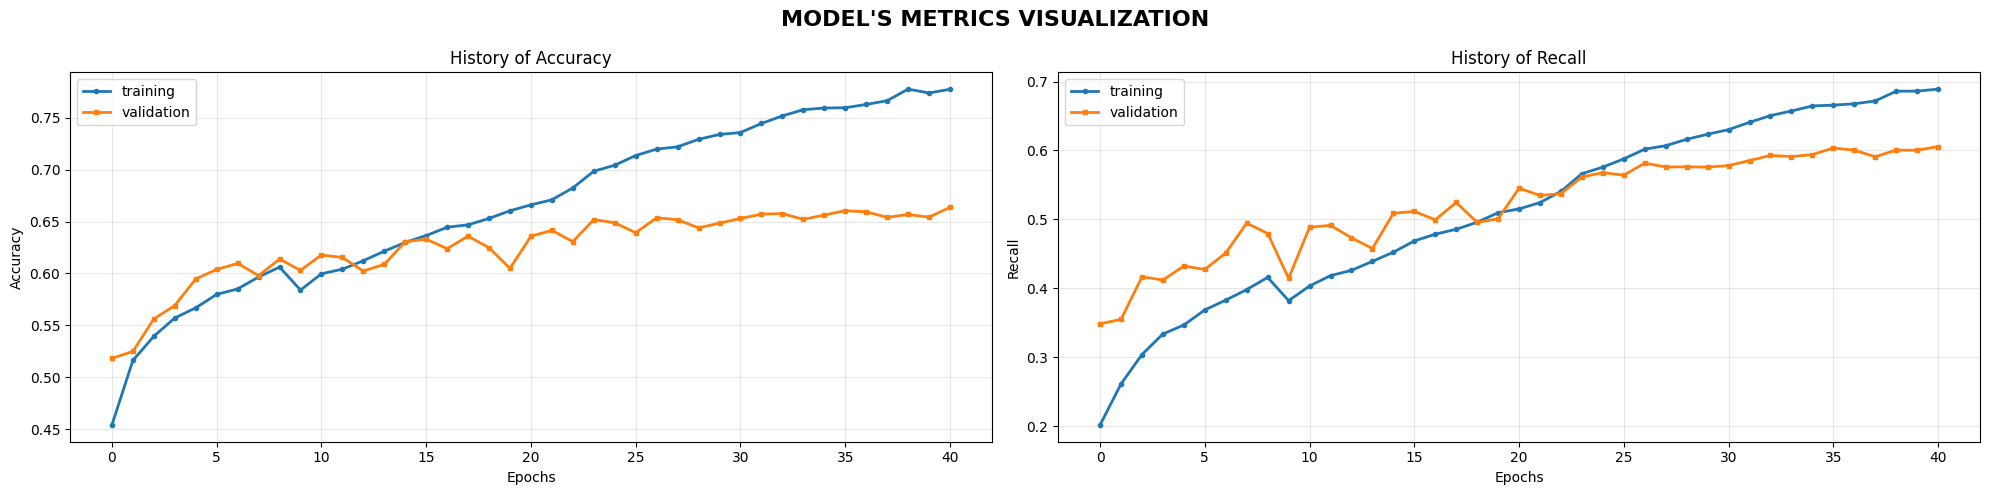

In [ ]:
csv_file = '/content/drive/MyDrive/Renan_ResNet50V2/fer2013_training_log.csv'
output_filename = '/content/drive/MyDrive/Renan_ResNet50V2/fer2013_new_model_metrics.png'
plot(csv_file, output_filename)

### Validation on Affectnet

In [ ]:
loss, accuracy, precision, recall, auc, f1_score_eval = model.evaluate(test_aff_dataset)
print(f'Model Evaluation Accuracy: {accuracy * 100:.2f}%')
print(f'Model Evaluation Precision: {precision * 100:.2f}%')
print(f'Model Evaluation Recall: {recall * 100:.2f}%')
print(f'Model Evaluation AUC: {auc * 100:.2f}%')
print(f'Model Evaluation F1-score: {f1_score_eval * 100:.2f}%')

207/207 ━━━━━━━━━━━━━━━━━━━━ 39s 153ms/step - accuracy: 0.5641 - auc: 0.8719 - f1_score: 0.3310 - loss: 1.9629 - precision: 0.6422 - recall: 0.4879
Model Evaluation Accuracy: 52.21%
Model Evaluation Precision: 60.17%
Model Evaluation Recall: 44.49%
Model Evaluation AUC: 84.54%
Model Evaluation F1-score: 32.92%


### Training on Affectnet

In [ ]:
lrd = ReduceLROnPlateau(monitor = 'val_loss',patience = 20,verbose = 1,factor = 0.50, min_lr = 1e-7, mode='min')

mcp = ModelCheckpoint('/content/model_affectnet_checkpoint.keras', save_best_only=True, verbose = 1)

es = EarlyStopping(verbose=1, patience=20, restore_best_weights=True)

### Loading model weights for Training

In [ ]:
model.load_weights('/content/model_affectnet_checkpoint.keras')

In [ ]:
model.compile(optimizer=Adam(1e-3),loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05), metrics=METRICS)

In [ ]:
history = model.fit(
    train_dataset,
    validation_data=valid_dataset,
    epochs=15,
    class_weight=class_weight_dict,
    callbacks=[lrd, mcp,es, csv_logger],
    initial_epoch=0
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
182/182 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4923 - auc: 0.8350 - f1_score: 0.4517 - loss: 1.5513 - precision: 0.6371 - recall: 0.3032
Epoch 1: val_loss improved from inf to 1.32879, saving model to /content/drive/MyDrive/Renan_ResNet50V2/affectnet/model_affectnet_checkpoint.keras
182/182 ━━━━━━━━━━━━━━━━━━━━ 275s 1s/step - accuracy: 0.4925 - auc: 0.8352 - f1_score: 0.4519 - loss: 1.5506 - precision: 0.6374 - recall: 0.3032 - val_accuracy: 0.5597 - val_auc: 0.8820 - val_f1_score: 0.4925 - val_loss: 1.3288 - val_precision: 0.6934 - val_recall: 0.4169 - learning_rate: 0.0010
Epoch 2/15
182/182 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5844 - auc: 0.8999 - f1_score: 0.5462 - loss: 1.2490 - precision: 0.7654 - recall: 0.3784
Epoch 2: val_loss improved from 1.32879 to 1.19930, saving model to /content/drive/MyDrive/Renan_ResNet50V2/affectnet/model_affectnet_checkpoint.keras
182/182 ━━━━━━━━━━━━━━━━━━━━ 227s 1s/step - accuracy: 0.5844 - auc: 0.8998 - f1_score: 0.5462 

KeyboardInterrupt: 

### Model efficiency on Affectnet

In [ ]:
loss, accuracy, precision, recall, auc, f1_score_eval = model.evaluate(test_aff_dataset)
print(f'Model Evaluation Accuracy: {accuracy * 100:.2f}%')
print(f'Model Evaluation Precision: {precision * 100:.2f}%')
print(f'Model Evaluation Recall: {recall * 100:.2f}%')
print(f'Model Evaluation AUC: {auc * 100:.2f}%')
print(f'Model Evaluation F1-score: {f1_score_eval * 100:.2f}%')

207/207 ━━━━━━━━━━━━━━━━━━━━ 39s 153ms/step - accuracy: 0.5641 - auc: 0.8719 - f1_score: 0.3310 - loss: 1.9629 - precision: 0.6422 - recall: 0.4879
Model Evaluation Accuracy: 52.21%
Model Evaluation Precision: 60.17%
Model Evaluation Recall: 44.49%
Model Evaluation AUC: 84.54%
Model Evaluation F1-score: 32.92%


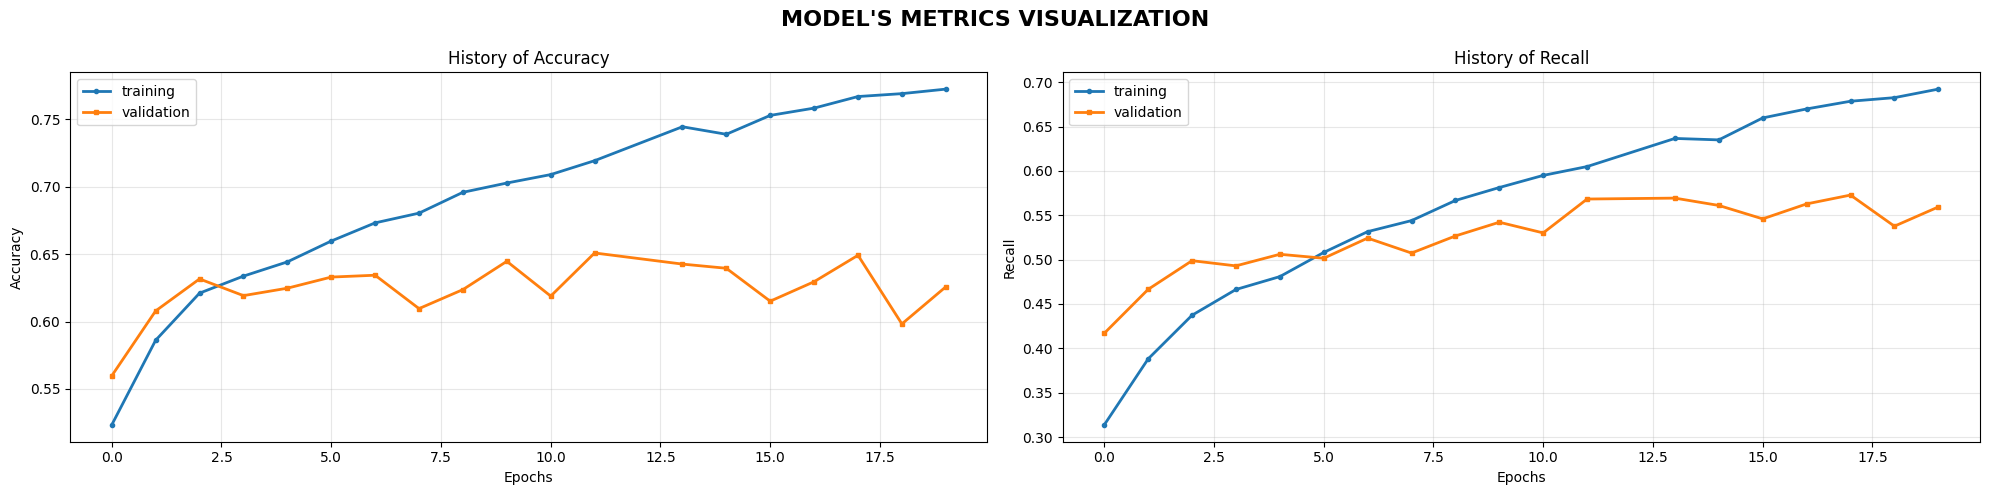

In [ ]:
csv_file = '/content/affectnet_training_log.csv'
output_filename = '/content/affectnet_model_metrics.png'
plot(csv_file, output_filename)


Noisy Images

In [ ]:
records = process_one_random_image_per_emotion(
  src_folder='affectnet_img/Train',
  dest_folder_noisy=f'/content/affectnet_result/mixed/',
  dest_folder_original=f'/content\/affectnet_result/original/'
)

survey_csv_path = '/content/survey_data.csv'
weights_df = build_condition_weights_from_survey(survey_csv_path)
summary_df = show_and_evaluate_records(
  model, weights_df, records, CLASS_ORDER,
  out_csv_path=f'/content/predictions_summary.csv'
)


Processing one random image per emotion: 100%|██████████| 7/7 [00:00<00:00, 26.73it/s]



True Class: Anger
Predicted Class: Anger
Anger: 0.489473
Disgust: 0.097595
Fear: 0.056677
Happy: 0.010548
Neutral: 0.031731
Sad: 0.290811
Surprise: 0.023165
Condition: stress
Scores: {'anxiety': np.float32(0.84057283), 'depression': np.float32(0.8971516), 'stress': np.float32(0.93194085)} 


True Class: Disgust
Predicted Class: Neutral
Anger: 0.099506
Disgust: 0.029172
Fear: 0.036811
Happy: 0.012076
Neutral: 0.503261
Sad: 0.263429
Surprise: 0.055746
Condition: stress
Scores: {'anxiety': np.float32(0.7439729), 'depression': np.float32(0.80610013), 'stress': np.float32(0.83121586)} 


True Class: Fear
Predicted Class: Fear
Anger: 0.031580
Disgust: 0.034043
Fear: 0.393866
Happy: 0.002319
Neutral: 0.005899
Sad: 0.220852
Surprise: 0.311440
Condition: anxiety
Scores: {'anxiety': np.float32(0.8683015), 'depression': np.float32(0.8474932), 'stress': np.float32(0.8650556)} 


True Class: Happy
Predicted Class: Happy
Anger: 0.004709
Disgust: 0.003262
Fear: 0.001885
Happy: 0.560222
Neutral: 0.42

Noiseless Images

In [ ]:
survey_csv_path = '/content/survey_data.csv'
weights_df = build_condition_weights_from_survey(survey_csv_path)
summary_df = show_and_evaluate_records(
    model, weights_df, records, CLASS_ORDER,
    out_csv_path=f'/content/predictions_summary_nonoise.csv'
)




True Class: Anger
Predicted Class: Anger
Anger: 0.489473
Disgust: 0.097595
Fear: 0.056677
Happy: 0.010548
Neutral: 0.031731
Sad: 0.290811
Surprise: 0.023165
Condition: stress
Scores: {'anxiety': np.float32(0.84057283), 'depression': np.float32(0.8971516), 'stress': np.float32(0.93194085)} 


True Class: Disgust
Predicted Class: Neutral
Anger: 0.099506
Disgust: 0.029172
Fear: 0.036811
Happy: 0.012076
Neutral: 0.503261
Sad: 0.263429
Surprise: 0.055746
Condition: stress
Scores: {'anxiety': np.float32(0.7439729), 'depression': np.float32(0.80610013), 'stress': np.float32(0.83121586)} 


True Class: Fear
Predicted Class: Fear
Anger: 0.031580
Disgust: 0.034043
Fear: 0.393866
Happy: 0.002319
Neutral: 0.005899
Sad: 0.220852
Surprise: 0.311440
Condition: anxiety
Scores: {'anxiety': np.float32(0.8683015), 'depression': np.float32(0.8474932), 'stress': np.float32(0.8650556)} 


True Class: Happy
Predicted Class: Happy
Anger: 0.004709
Disgust: 0.003262
Fear: 0.001885
Happy: 0.560222
Neutral: 0.42

### Validation on FER2013

In [ ]:
loss, accuracy, precision, recall, auc, f1_score_eval = model.evaluate(test_fer_dataset)
print(f'Model Evaluation Accuracy: {accuracy * 100:.2f}%')
print(f'Model Evaluation Precision: {precision * 100:.2f}%')
print(f'Model Evaluation Recall: {recall * 100:.2f}%')
print(f'Model Evaluation AUC: {auc * 100:.2f}%')
print(f'Model Evaluation F1-score: {f1_score_eval * 100:.2f}%')

113/113 ━━━━━━━━━━━━━━━━━━━━ 18s 160ms/step - accuracy: 0.4583 - auc: 0.7942 - f1_score: 0.4075 - loss: 1.8672 - precision: 0.5109 - recall: 0.3736
Model Evaluation Accuracy: 45.33%
Model Evaluation Precision: 51.38%
Model Evaluation Recall: 37.36%
Model Evaluation AUC: 79.57%
Model Evaluation F1-score: 40.14%
